In [ ]:
from google.colab import files
uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset (4).csv


In [ ]:
#SECTION 1 - IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,5)
print("Libraries imported successfully!")


Libraries imported successfully!


In [65]:
#SECTION 2 - LOAD AND EXPLORE THE DATA

df = pd.read_csv('/content/retail_sales_dataset.csv')
print("Shape:", df.shape)
df.head(10)

Shape: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,24-11-2023,CUST001,Male,34,Beauty,3,50,150
1,2,27-02-2023,CUST002,Female,26,Clothing,2,500,1000
2,3,13-01-2023,CUST003,Male,50,Electronics,1,30,30
3,4,21-05-2023,CUST004,Male,37,Clothing,1,500,500
4,5,06-05-2023,CUST005,Male,30,Beauty,2,50,100
5,6,25-04-2023,CUST006,Female,45,Beauty,1,30,30
6,7,13-03-2023,CUST007,Male,46,Clothing,2,25,50
7,8,22-02-2023,CUST008,Male,30,Electronics,4,25,100
8,9,13-12-2023,CUST009,Male,63,Electronics,2,300,600
9,10,07-10-2023,CUST010,Female,52,Clothing,4,50,200


In [66]:
# Data tyoes and basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [67]:
#check missing values
print("Missing values:")
print(df.isnull().sum())


Missing values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [68]:
#check duplicates
print("\nDuplicate Rows:",df.duplicated().sum())


Duplicate Rows: 0


In [69]:
#SECTION 3- DATA CLEANING
#Remove duplicates if any

df.drop_duplicates(inplace=True)

#convert data column to datetime format
df['Date']=pd.to_datetime(df['Date'])

#Extract month and year from date - useful for time series later
df['month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')# jan, feb, etc
df['year'] =df['Date'].dt.year

print("Cleaning done!")
print("Shape after cleaning:",df.shape)
df.head()

Cleaning done!
Shape after cleaning: (1000, 12)


/tmp/ipykernel_11670/4153525188.py:7: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date']=pd.to_datetime(df['Date'])


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,month,Month_Name,year
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,Nov,2023
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,Feb,2023
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,Jan,2023
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,May,2023
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,May,2023


In [70]:
#section4 - descriptive statistics

print("===Basics Statistics ===")
df.describe()

===Basics Statistics ===


,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount,month,year
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000,6.549000,2023.002000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000,1.000000,2023.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000,4.000000,2023.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000,6.000000,2023.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000,10.000000,2023.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000,12.000000,2024.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632,3.452755,0.044699


In [71]:
# statistics per product category

print("==total sales by product category===")
print(df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False))

==total sales by product category===
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


In [72]:
# statistics per gender
print("Average Purchase by  Gender ===")
print(df.groupby('Gender')['Total Amount'].mean())

Average Purchase by  Gender ===
Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64


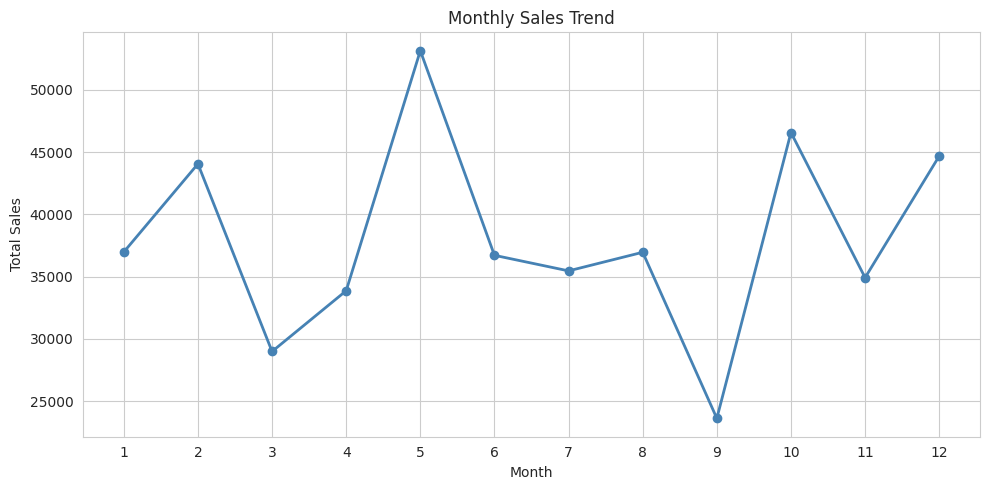

Best Month: 5
Worst Month: 9


In [73]:
#section5 -Time Series Analysis

#Monthly sales trend
monthly_sales = df.groupby('month')['Total Amount'].sum().reset_index()
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['month'],monthly_sales['Total Amount'],
         marker ='o' , linewidth=2, color='steelblue')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1,13))
plt.tight_layout()
plt.savefig('monthly_sales.png',dpi=150)
plt.show()

print("Best Month:", monthly_sales.loc[monthly_sales['Total Amount'].idxmax(), 'month'])
print("Worst Month:", monthly_sales.loc[monthly_sales['Total Amount'].idxmin(), 'month'])

Section 6 - Customer & Producst Analysis

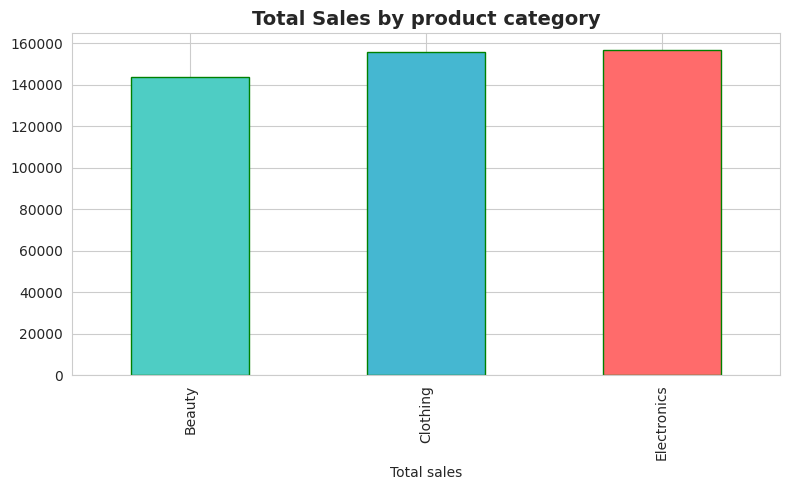

In [74]:
import matplotlib.pyplot as plt
# section 6 - Sales by  product Analysis

plt.figure(figsize =(8,5))
df.groupby('Product Category')['Total Amount'].sum().sort_values().plot(kind='bar', color=['#4ECDC4', '#45B7D1','#FF6B6B'],edgecolor='Green')
plt.title('Total Sales by product category', fontsize=14, fontweight ='bold')
plt.xlabel('Total sales')
plt.tight_layout()
plt.savefig('product_sales.png',dpi=150)
plt.show()

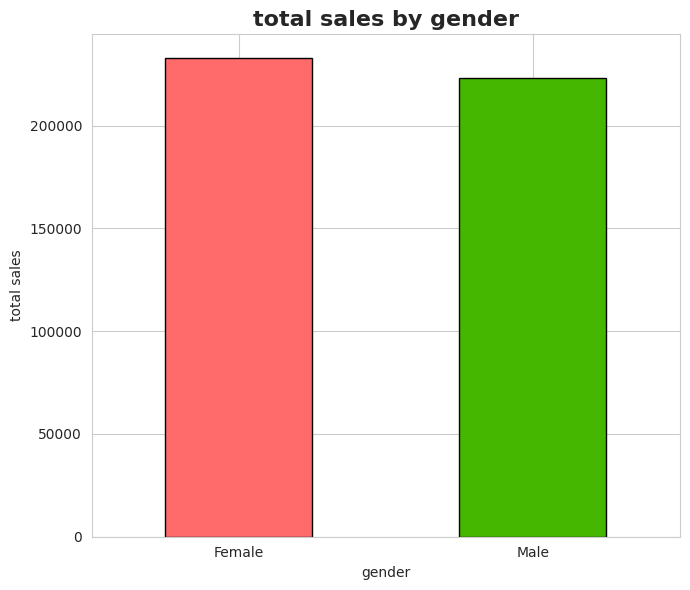

In [75]:
import matplotlib.pyplot as plt
#sals by gender
plt.figure(figsize =(7,6))
df.groupby('Gender')['Total Amount'].sum().plot(kind='bar',color=['#FF6B6B','#45B701'],edgecolor='black')
plt.title('total sales by gender',fontsize=16 , fontweight='bold')
plt.xlabel('gender')
plt.ylabel('total sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sales_by_gender.png',dpi=200)
plt.show()

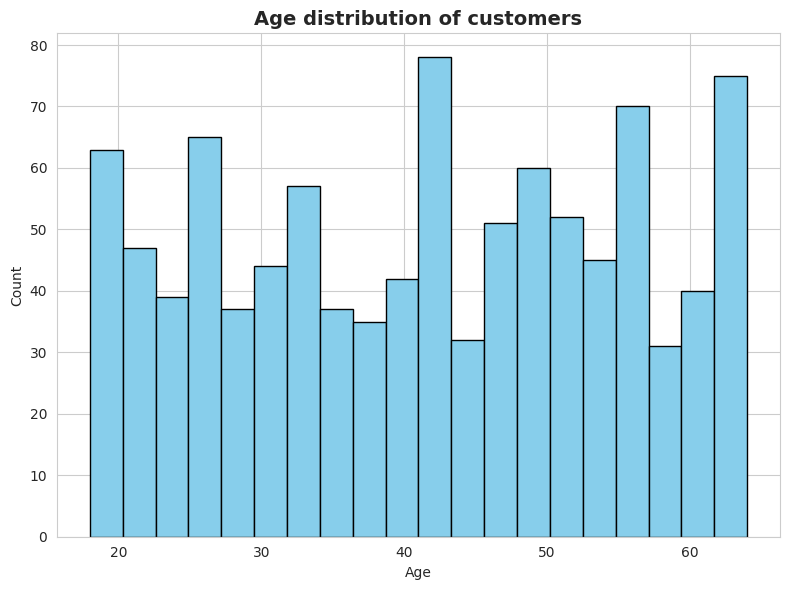

In [76]:
#age distribution of customers
plt.figure(figsize=(8,6))
plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Age distribution of customers', fontsize =14 , fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('age_distribution.png',dpi = 155)
plt.show()

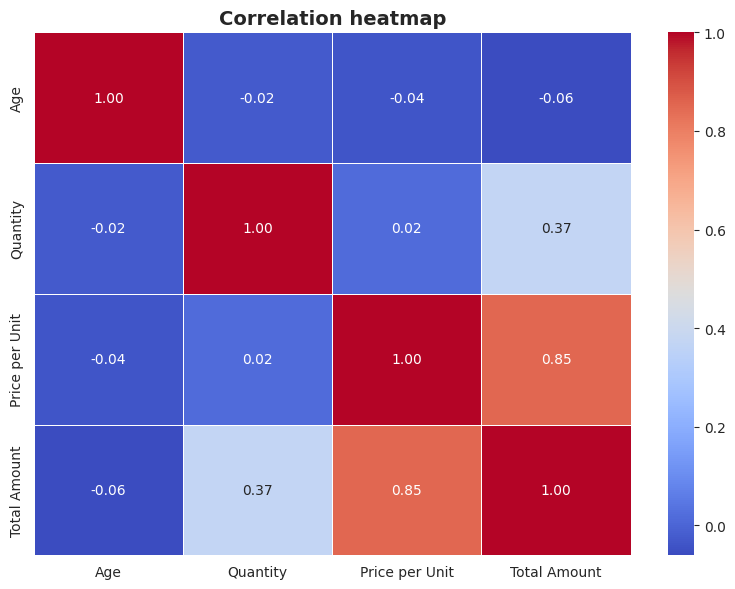

In [ ]:
#correlation heatmap

plt.figure (figsize=(8,6))
sns.heatmap(df[['Age','Quantity','Price per Unit','Total Amount']].corr(),annot= True,cmap='coolwarm',fmt='.2f',linewidth=0.6)
plt.title('Correlation heatmap',fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap.png',dpi=150)
plt.show()